# Visualising datasets

## 0.1. Imports and load data

In [2]:
import ase.io
import os
from pathlib import Path
import numpy as np
import importlib
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist

from mace import modules
from mace.data.atom_data_loader import AtomDataLoaderBuilder
from mace.testing import Tester
from mace.training import FreezeStrategy, NaiveStrategy, Trainer, initialise_autoencoder

import sampling_methods.descriptors as descriptors
import sampling_methods.selectors as selectors
import utils.training as training

importlib.reload(descriptors)
importlib.reload(selectors)
importlib.reload(training)

MAX_EPOCHS = 10
R_MAX = 5.0
BATCH_SIZE = 16
BASE_LR = 1.0e-3
TRANSFER_LR = 5.0e-4
DEVICE = torch.device("cpu")

# define wrapper classes
data_builder = AtomDataLoaderBuilder(
    cutoff=R_MAX, energy_key="REF_energy", forces_key="REF_forces"
)



In [3]:
ROOT_PATH = Path.cwd()
DATA_DIR = ROOT_PATH / "../data"

# dataset for training the base model, ie foundation/pre-trained model
BASE_XYZ = DATA_DIR / "A02_propene_grid_static.xyz"
BASE_N_GEOMETRIES = 3731  # number of geometries to use from the base dataset

# dataset for transfer learning
TRANSFER_XYZ = DATA_DIR / "casscf_44_propene_full.xyz"
TRANSFER_N_GEOMETRIES = 3731 # number of geometries to use from the transfer dataset

OUTPUT_DIR = ROOT_PATH / "../outputs"

base_atoms_list = ase.io.read(BASE_XYZ, index=f":{BASE_N_GEOMETRIES}")
transfer_atoms_list = ase.io.read(TRANSFER_XYZ, index=f":{TRANSFER_N_GEOMETRIES}")

print("base_atoms_list length:", len(base_atoms_list))
print("transfer_atoms_list length:", len(transfer_atoms_list))


base_atoms_list length: 3731
transfer_atoms_list length: 3731


## 0.2. Split into test, train, valid sets

In [4]:
# get bond lengths and dihedrals
# tested on propene only

desc_matrix = []
bond_lengths = []
dihedrals = []

for atom in base_atoms_list:
    bond_length = descriptors.get_descriptor("bond_lengths",atom)[0]
    dihedral = descriptors.get_descriptor("dihedral",atom)[0]
    
    bond_lengths.append(bond_length)
    dihedrals.append(dihedral)
    desc_matrix.append([bond_length, dihedral])

desc_matrix = np.asarray(desc_matrix)

# extract test set
# the same test set is removed from both base and transfer datasets

TEST_SET_FRACTION = 0.1
TEST_SET_SIZE = int(np.floor(int(BASE_N_GEOMETRIES) * TEST_SET_FRACTION))

test_set_idx = selectors.get_selector("uniform_grid", desc_matrix, TEST_SET_SIZE)
base_test_set = [base_atoms_list[i] for i in test_set_idx]
transfer_test_set = [transfer_atoms_list[i] for i in test_set_idx]
print("Test set size:", len(base_test_set))

# remaining geometries are for training and validation
train_valid_set_idx = np.setdiff1d(np.arange(len(transfer_atoms_list)), test_set_idx)
base_train_valid_set = [base_atoms_list[i] for i in train_valid_set_idx]
transfer_train_valid_set = [transfer_atoms_list[i] for i in train_valid_set_idx]

# split remaining geometries into train and valid sets
# the same for both base and transfer datasets

SEED = 42 # set as int to get the same split every time
VALID_SET_FRACTION = 0.1 # as a fraction of the total dataset

train_set_idx, valid_set_idx = train_test_split(
    train_valid_set_idx, test_size=VALID_SET_FRACTION/(1-TEST_SET_FRACTION), random_state=SEED, shuffle=True
)

base_train_set = [base_atoms_list[i] for i in train_set_idx]
print("\nBase train set size:", len(base_train_set))
base_valid_set = [base_atoms_list[i] for i in valid_set_idx]
print("Base valid set size:", len(base_valid_set))

transfer_train_set = [transfer_atoms_list[i] for i in train_set_idx]
print("\nFull high-fidelity train set size:", len(transfer_train_set))
transfer_valid_set = [transfer_atoms_list[i] for i in valid_set_idx]
print("Full high-fidelity valid set size:", len(transfer_valid_set))


Test set size: 361

Base train set size: 2995
Base valid set size: 375

Full high-fidelity train set size: 2995
Full high-fidelity valid set size: 375


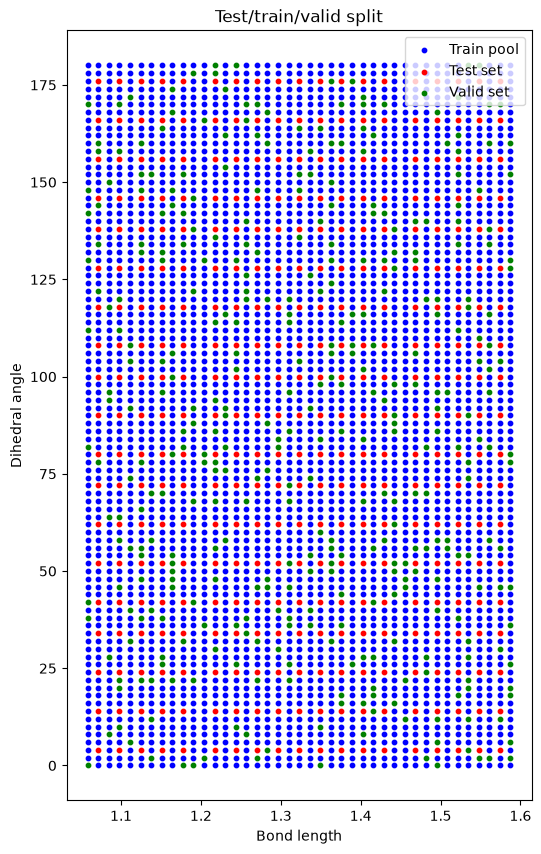

In [13]:
# visualise
%matplotlib inline

plt.figure(figsize=(6, 10))  

plt.scatter([bond_lengths[i] for i in train_set_idx],
            [dihedrals[i] for i in train_set_idx], 
            color='blue', marker='o', s=10, label='Train pool')

plt.scatter([bond_lengths[i] for i in test_set_idx], 
            [dihedrals[i] for i in test_set_idx], 
            color='red', marker='o', s=10, label='Test set')

plt.scatter([bond_lengths[i] for i in valid_set_idx], 
            [dihedrals[i] for i in valid_set_idx], 
            color='green', marker='o', s=10, label='Valid set')

plt.title("Test/train/valid split")
plt.xlabel("Bond length")
plt.ylabel("Dihedral angle")
plt.legend()

plt.show()

## 0.3. Descriptor

In [36]:
# load base model and encoder

base_model_filename = "base_model_propene_3731_geometries.pt"
base_model_save_path = OUTPUT_DIR / "base_models" / base_model_filename
base_model = torch.load(base_model_save_path, weights_only=False)

base_model.eval()

base_encoder = base_model.perm_encoder

In [58]:
DESCRIPTOR_TYPE = ["bond_lengths", "bond_angles", "dihedral", "energies", "encoded_energies", "soap", "acsf", "mbtr"]
DESCRIPTOR = DESCRIPTOR_TYPE[3]  # choose the descriptor type to use

# matrix of descriptors for each geometry
# sampling is done on base dataset, out of the training pool only
# ie test and valid sets are already removed
desc_matrix = []
for atom in base_train_set:
    desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom,base_encoder))
desc_matrix = np.asarray(desc_matrix)

# n*m, where n is the number of geometries and m is the dimension of the descriptor
# eg if we use bond_lengths and propene, m=2 because there's 2 CC bonds in propene
print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)


desc_matrix shape: (2995, 3)
desc_matrix unique shape: (2995, 3)
desc_matrix:
 [[-3183.12307478 -3176.68833297 -3173.76812945]
 [-3181.88910645 -3177.91903594 -3176.29877477]
 [-3181.28782189 -3175.50537238 -3171.41470917]
 ...
 [-3181.11625138 -3178.35955563 -3178.16638744]
 [-3183.39478864 -3175.71783072 -3165.72083817]
 [-3184.03173916 -3176.23632191 -3171.42583047]]


In [37]:
# run this to use latent space as descriptor

from mace.testing import extract_latent_space

DESCRIPTOR = 'latent_space'

base_train_loader_unshuffle = data_builder.load(
    base_train_set, batch_size=BATCH_SIZE, shuffle=False
)
latent_space = extract_latent_space(
    base_model, base_train_loader_unshuffle, device=DEVICE
)

desc_matrix = latent_space
print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)

desc_matrix shape: (2995, 16)
desc_matrix unique shape: (2995, 16)
desc_matrix:
 [[-1.2087054   0.11680095 -0.5589149  ... -1.3300848   1.7829703
   0.90153855]
 [-1.1781795   0.1718116  -0.5746635  ... -1.3111407   1.8391098
   0.87157404]
 [-1.1917729   0.29069722 -0.6382212  ... -1.2045417   1.9290845
   0.7771661 ]
 ...
 [-1.1842715   0.14935547 -0.5658525  ... -1.3272974   1.8163601
   0.88567406]
 [-1.1548558   0.20012794 -0.58014446 ... -1.2892287   1.8898118
   0.8643158 ]
 [-1.179636    0.11040239 -0.545122   ... -1.3495538   1.801417
   0.92102194]]


## 0.4. Selector

In [59]:
SELECTOR_TYPE = ["random_sampling", "farthest_point_sampling", "k_means_clustering", "k_means_clustering_weighted", "birch", "birch_weighted", "dbscan", "dbscan_weighted"]
SELECTOR = SELECTOR_TYPE[3]  # choose the selector type to use

# number of samples to select from the transfer dataset
N_SAMPLES = 100

# select samples based on the descriptor matrix
sampled_idx = selectors.get_selector(SELECTOR, desc_matrix, N_SAMPLES, n_clusters=25)

# sample atoms out of transfer dataset
sampled_atoms = [transfer_train_set[i] for i in sampled_idx]

print("sampled indices:\n", sampled_idx)
print("number sampled:", len(sampled_idx))

n clusters: 25
n clusters with samples: 25
labels: [24  2 17 ...  5  8 19]
allocation: [ 2  1 11  5  5 11  1  7  2  2  1  2  4  2  2  2  6  2  7  7  4  1  2  4
  7]
sampled indices:
 [1121  227  764 2207 2569 2712 2008 2628  603  662  415  527 2677  167
 2980  334  914 2432  726  618 2605 1547 2926 2190  260 1665  645 2450
 2341 2029 2311 1935 1256 2614 2564 2581 1053 1129 1892  742 2691  922
 1152 1195 2248  271 2571 1797 1658  214 1560 1240 2026 2049  557 2836
 1023 2046  689 1213  406  905 1610 1078 1447 1699 1793  343  958  967
 1227  463  284  879   25  727 2140 1267  903 2994 1277  383 1261   16
  551 1599 1485 1151 2155  151  498   41 2483 2446 2417  680 2807 2357
 1508  308]
number sampled: 100


## 1. PCA plot

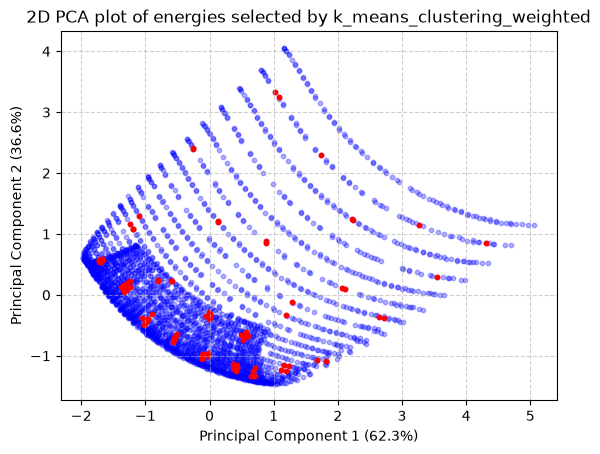

In [61]:
# 2D PCA
%matplotlib inline

desc_matrix_scaled = StandardScaler().fit_transform(desc_matrix)

pca = PCA(n_components=2)
desc_matrix_pca = pca.fit_transform(desc_matrix_scaled)

plt.scatter(desc_matrix_pca[:,0], desc_matrix_pca[:,1], color='blue', marker='o', alpha=0.3, s=10)
plt.scatter(
    desc_matrix_pca[sampled_idx, 0],
    desc_matrix_pca[sampled_idx, 1],
    color='red',
    marker='o',
    alpha=1,
    s=10,
    label='Sampled'
)

plt.title(f'2D PCA plot of {DESCRIPTOR} selected by {SELECTOR}')
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()


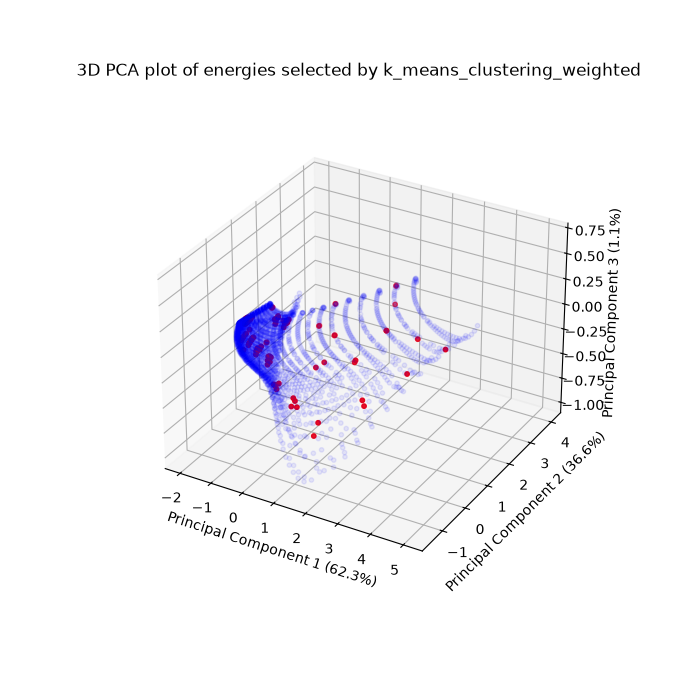

In [62]:
# 3D PCA
%matplotlib widget

desc_matrix_scaled = StandardScaler().fit_transform(desc_matrix)

pca = PCA(n_components=3)
desc_matrix_pca = pca.fit_transform(desc_matrix_scaled)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(projection='3d')
ax.set_box_aspect(None, zoom=0.85)

ax.scatter(desc_matrix_pca[:,0], desc_matrix_pca[:,1], desc_matrix_pca[:,2], color='blue', marker='o', alpha=0.3, s=10)
ax.scatter(
    desc_matrix_pca[sampled_idx, 0],
    desc_matrix_pca[sampled_idx, 1],
    desc_matrix_pca[sampled_idx, 2],
    color='red',
    marker='o',
    alpha=1,
    s=10,
    label='Sampled'
)

plt.title(f'3D PCA plot of {DESCRIPTOR} selected by {SELECTOR}')
ax.set_xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"Principal Component 3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()


## 2. Distances between points

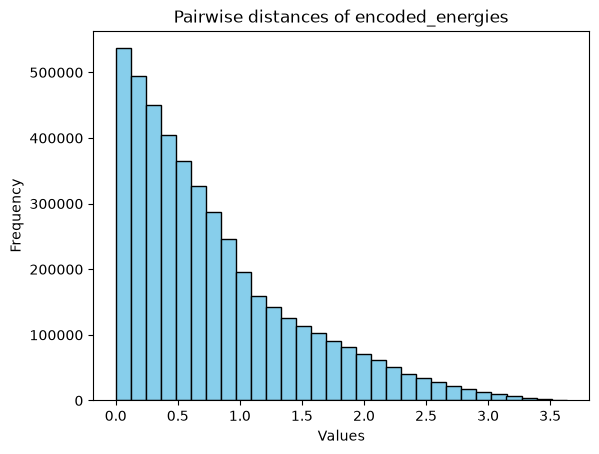

In [15]:
# Pairwise distances
%matplotlib inline

distances = pdist(desc_matrix)

plt.hist(distances, bins=30, color='skyblue', edgecolor='black')

plt.title(f'Pairwise distances of {DESCRIPTOR}')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()

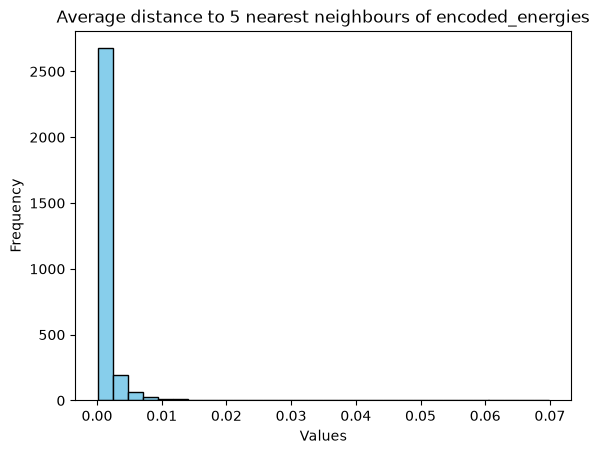

In [16]:
# Average distance to n nearest neighbours

N_NEIGHBORS = 5

nbrs = NearestNeighbors(n_neighbors=N_NEIGHBORS).fit(desc_matrix)
distances, _ = nbrs.kneighbors(desc_matrix)

avg_distances = distances.mean(axis=1)

plt.hist(avg_distances, bins=30, color='skyblue', edgecolor='black')

plt.title(f'Average distance to {N_NEIGHBORS} nearest neighbours of {DESCRIPTOR}')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()

## 3. Density

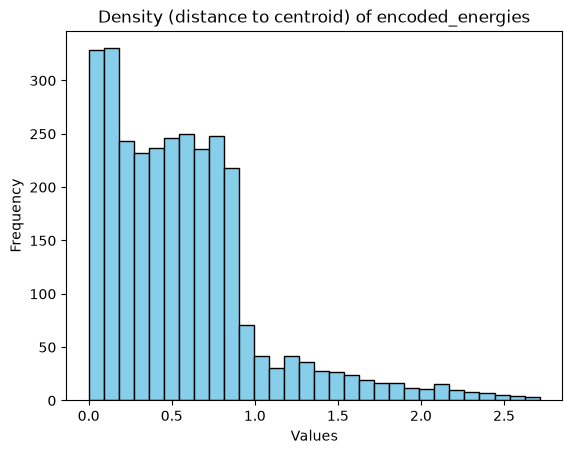

In [17]:
# Distances of all points to centroid

center = desc_matrix.mean(axis=0)
distances = np.linalg.norm(desc_matrix - center, axis=1)

plt.hist(distances, bins=30, color='skyblue', edgecolor='black')

plt.title(f'Density (distance to centroid) of {DESCRIPTOR}')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()


## 4. View molecules

In [11]:
from ase.visualize import view
view(base_atoms_list)

<Popen: returncode: None args: ['/home/lim_yt/micromamba/envs/xmace311/bin/p...>